In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass","sex", "fare", "age", "embarked"]
target = ["survived"]

In [33]:
from sklearn.impute import SimpleImputer
imp_med = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_med.fit_transform(titanic[["age"]])
imp_freq= SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])
x= titanic[features]
y = titanic["survived"]

In [34]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [35]:
titanic.shape

(891, 15)

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [37]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [38]:
x =titanic[features]
y = titanic[target]

In [39]:
x.head()

,pclass,sex,fare,age,embarked
0,3,1,7.2500,22.0,2
1,1,0,71.2833,38.0,0
2,3,0,7.9250,26.0,2
3,1,0,53.1000,35.0,2
4,3,1,8.0500,35.0,2


In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [41]:
x_test.head()

,pclass,sex,fare,age,embarked
709,3,1,15.2458,28.0,0
439,2,1,10.5000,31.0,2
840,3,1,7.9250,20.0,2
720,2,0,33.0000,6.0,2
39,3,0,11.2417,14.0,0


In [42]:
#IMPLEMENTATION OF DEcision TREE WITHOUT PRUNNING
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
from sklearn.metrics import accuracy_score, precision_score
y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)
print("accuracy for testing data:", accuracy_score(y_test, y_pred_test))
print("accuracy for training data:", accuracy_score(y_train, y_pred_train))

#here low bias and high variance. this is classic case of overfitting. to correct this we will implement random forest.


accuracy for testing data: 0.776536312849162
accuracy for training data: 0.9775280898876404


In [44]:
#IMPLEMENTATION OF RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf =RandomForestClassifier(
    n_estimators = 201,
    oob_score = True
)
rf.fit(x_train, y_train)
y_predict = rf.predict(x_test)
print("accuracy of testing data:", accuracy_score(y_test, y_predict))
print("oob_score", rf.oob_score_)
        


accuracy of testing data: 0.7988826815642458
oob_score 0.8089887640449438


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


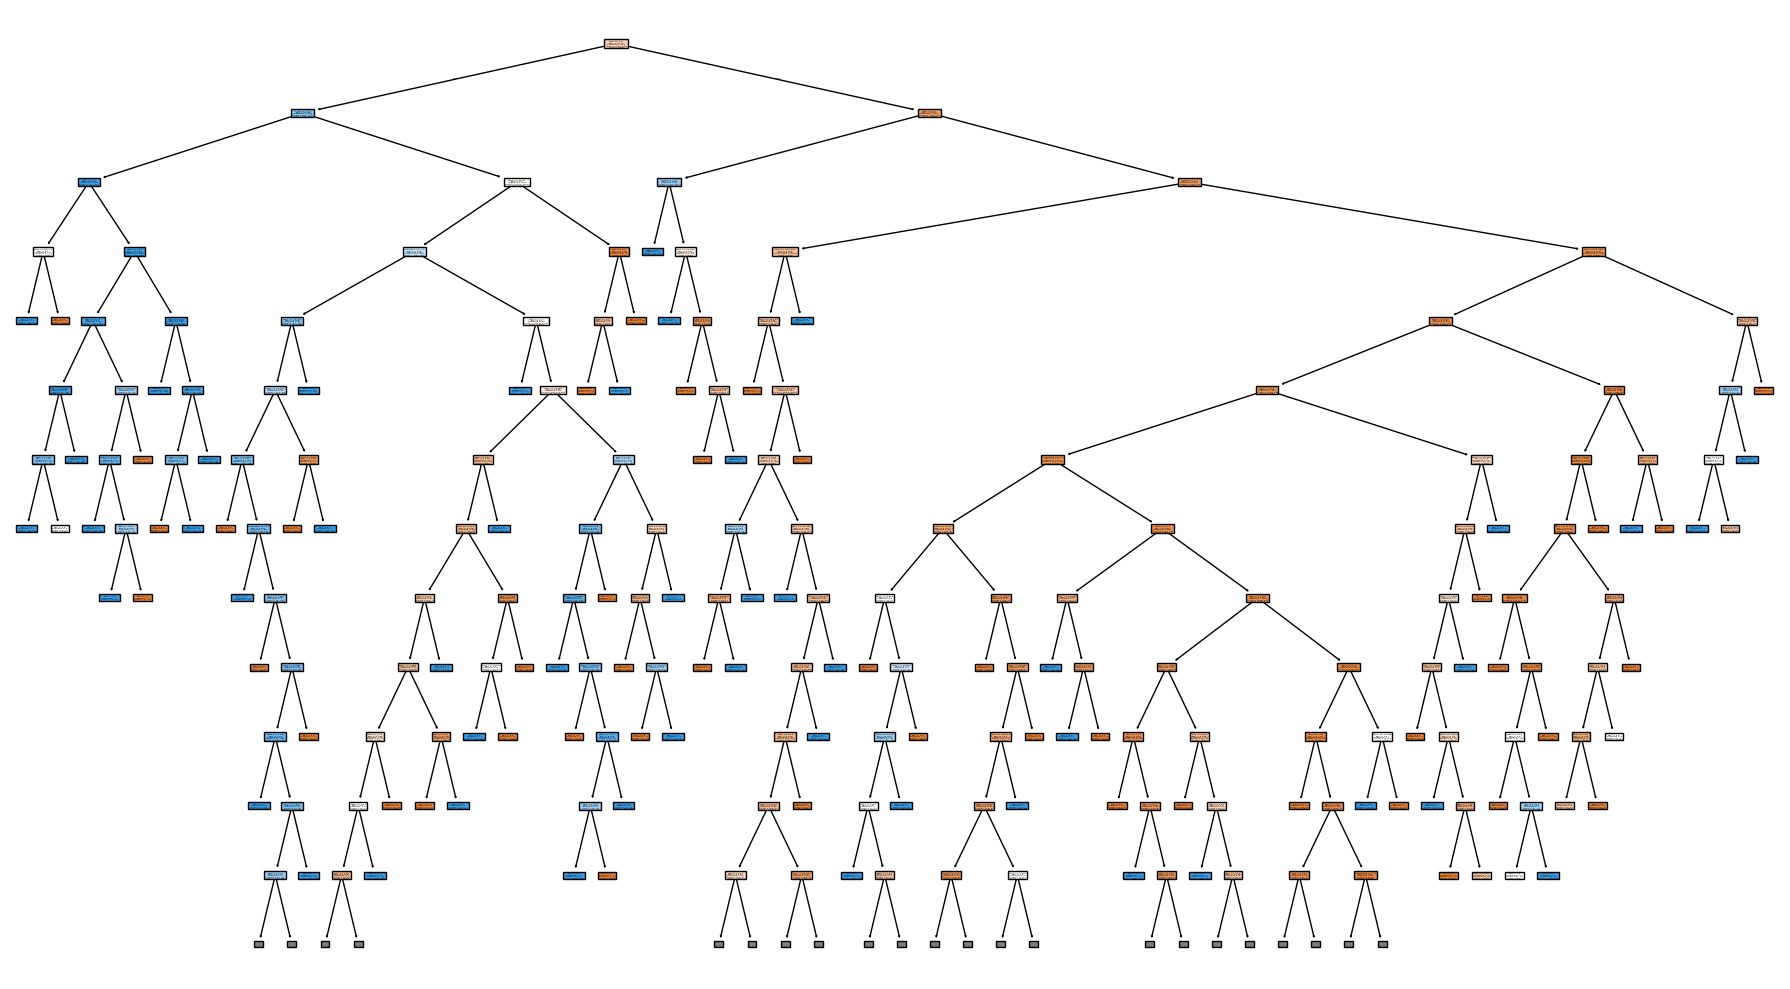

In [78]:
from sklearn.tree import plot_tree
plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["died", "survived"],
    filled = True,
    max_depth = 12
)
plt.tight_layout()
plt.show()
    


In [82]:
#pre_pruning
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    print(f" for depth{depth}, accuracy={acc}")

 for depth2, accuracy=0.7653631284916201
 for depth3, accuracy=0.7988826815642458
 for depth4, accuracy=0.7988826815642458
 for depth5, accuracy=0.7988826815642458
 for depth6, accuracy=0.8044692737430168
 for depth7, accuracy=0.7932960893854749
 for depth8, accuracy=0.7821229050279329
 for depth9, accuracy=0.7877094972067039
 for depth10, accuracy=0.7821229050279329


 for depth10, accuracy=0.8044692737430168
 for depth10, accuracy=0.7932960893854749
 for depth10, accuracy=0.8044692737430168
 for depth10, accuracy=0.8044692737430168
 for depth10, accuracy=0.7988826815642458


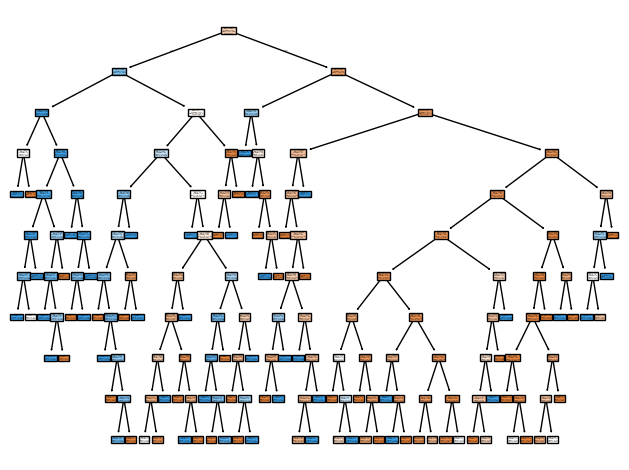

In [85]:
min_sample_splits = [10, 15, 20, 25, 30]
for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    print(f" for depth{depth}, accuracy={acc}")
    if depth == 4:
      plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["died", "survived"],
    filled = True,
    max_depth = 12
)
plt.tight_layout()
plt.show()

In [86]:
#POST PRUNING
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [87]:
path = full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [89]:
#train our model for all alphas
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_test, y_test)

    trees.append((model, alpha))

In [97]:
best_acc = 0
best_alpha = 0
for model,alpha in trees:
    curr_acc = model.score(x_test,y_test)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_alpha = alpha

In [99]:
best_alpha

np.float64(0.13777997649438206)

In [100]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


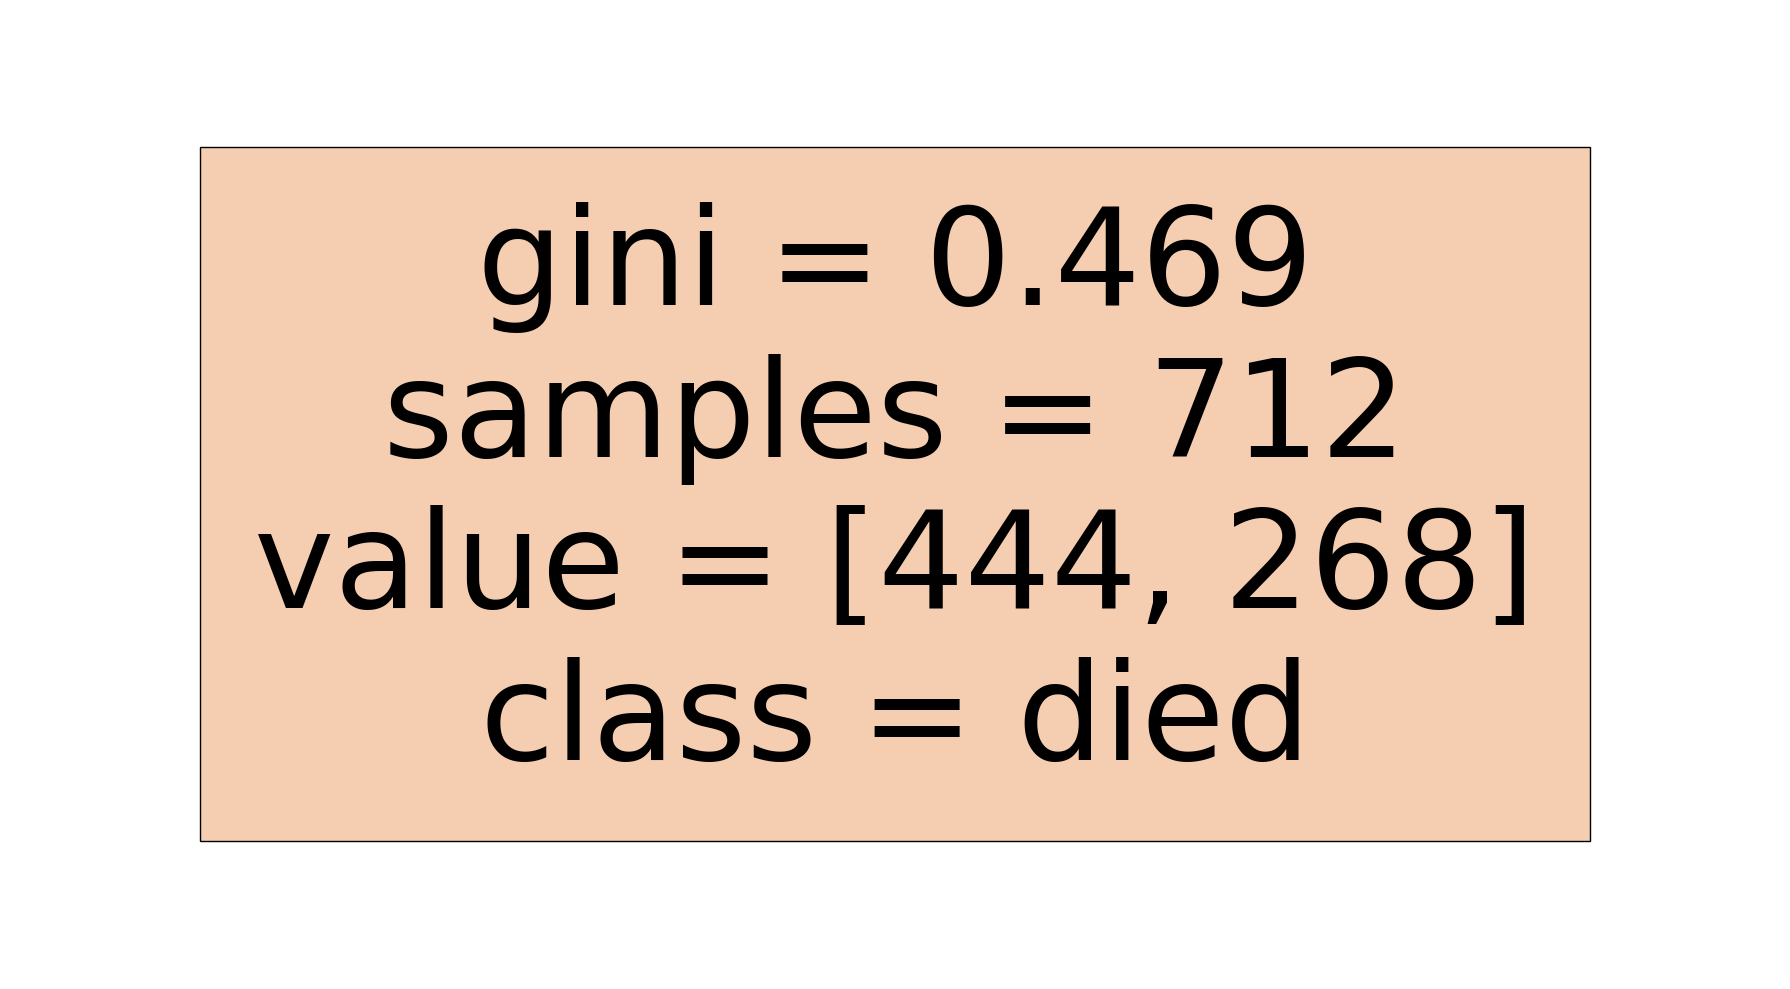

In [101]:
plt.figure(figsize = (18, 10))
plot_tree(
    best_model,
    feature_names = x.columns,
    class_names = ["died", "survived"],
    filled = True,
)
plt.tight_layout()
plt.show()

In [46]:
#bagging classifier
from sklearn.ensemble import BaggingClassifier
base_model = DecisionTreeClassifier(max_depth = 4)
bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(x_train, y_train)
y_pred_test = bagging.predict(x_test)
print("accuracy of testing data:", accuracy_score(y_test, y_predict))


accuracy of testing data: 0.7988826815642458


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
#bagging classifier
from sklearn.ensemble import BaggingClassifier
base_model = DecisionTreeClassifier(max_depth = 4)
bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(x_train, y_train)
y_pred_test = bagging.predict(x_test)
print("accuracy of testing data:", accuracy_score(y_test, y_predict))


accuracy of testing data: 0.7988826815642458


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
